# LSM vs TD-LSM for American Put Option

**Standard LSM (Longstaff-Schwartz):** At time step `t`, regress on the *realized discounted cashflows* from following the optimal policy at future steps. The cashflow table is built by walking backward: if exercise is optimal at `t`, the cashflow is the immediate payoff; otherwise it's the discounted cashflow from the *next* time the option is exercised.

**TD-LSM (Temporal Difference LSM):** At time step `t`, instead of using realized cashflows, use a *one-step bootstrap*: the continuation target is `discount * max(payoff(t+1), predicted_continuation(t+1))`, where `predicted_continuation(t+1)` comes from the regressor already trained at `t+1`.

This mirrors the MC → TD transition in RL. MC uses full returns; TD bootstraps from value estimates.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import time
from dataclasses import dataclass

np.random.seed(42)

@dataclass
class Params:
    S0: float = 100.0
    K: float = 100.0
    T: float = 1.0
    r: float = 0.05
    sigma: float = 0.3
    N: int = 500      # number of exercise dates
    
    @property
    def dt(self): return self.T / self.N
    
    @property
    def df(self): return np.exp(-self.r * self.dt)

params = Params()
print(f"American Put: S0={params.S0}, K={params.K}, T={params.T}, r={params.r}, σ={params.sigma}, N={params.N}")
print(f"dt={params.dt:.4f}, discount_factor={params.df:.6f}")

American Put: S0=100.0, K=100.0, T=1.0, r=0.05, σ=0.3, N=500
dt=0.0020, discount_factor=0.999900


In [12]:
def generate_gbm_paths(params, n_paths, seed=None):
    """Generate GBM paths. Shape: (n_paths, N+1)"""
    if seed is not None:
        np.random.seed(seed)
    dt = params.dt
    Z = np.random.standard_normal((n_paths, params.N))
    drift = (params.r - 0.5 * params.sigma**2) * dt
    diffusion = params.sigma * np.sqrt(dt) * Z
    log_returns = np.cumsum(drift + diffusion, axis=1)
    paths = np.zeros((n_paths, params.N + 1))
    paths[:, 0] = params.S0
    paths[:, 1:] = params.S0 * np.exp(log_returns)
    return paths

# Generate train / test split
train_paths = generate_gbm_paths(params, 100000, seed=42)
test_paths  = generate_gbm_paths(params, 10000, seed=999)
print(f"Train paths: {train_paths.shape}, Test paths: {test_paths.shape}")

Train paths: (100000, 501), Test paths: (10000, 501)


In [13]:
def poly_basis(S, degree=3):
    """Polynomial basis: [1, s, s^2, ..., s^degree] where s = S/K (normalized)."""
    s = S / params.K
    return np.column_stack([s**i for i in range(degree + 1)])

In [14]:
def train_lsm(paths, params, degree=3):
    """
    Standard Longstaff-Schwartz.
    Returns dict of regression coefficients: {t: coeffs}
    """
    N, df, K = params.N, params.df, params.K
    n_paths = len(paths)
    payoffs = np.maximum(K - paths, 0)  # (n_paths, N+1)
    
    # cashflows[i] = discounted cashflow for path i from the optimal future exercise
    cashflows = payoffs[:, N].copy()  # at maturity, exercise if ITM
    
    models = {}
    
    for t in range(N - 1, 0, -1):
        cashflows *= df  # discount one step back
        
        itm = payoffs[:, t] > 0
        if itm.sum() < degree + 5:
            continue
        
        X = poly_basis(paths[itm, t], degree)
        Y = cashflows[itm]  # realized discounted cashflows
        
        coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
        models[t] = coeffs
        
        continuation_est = X @ coeffs
        exercise = payoffs[itm, t] > continuation_est
        
        # Update cashflows: if exercise is optimal, replace with immediate payoff
        cashflows[itm] = np.where(exercise, payoffs[itm, t], cashflows[itm])
    
    return models

print("Standard LSM defined.")

Standard LSM defined.


In [ ]:
def train_td_lsm(paths, params, degree=3):
    """
    TD-LSM: one-step TD-style targets.
    At time t, continuation target = df * max(payoff(t+1), predicted_cont(t+1))
    """
    N, df, K = params.N, params.df, params.K
    payoffs = np.maximum(K - paths, 0)
    
    models = {}
    
    # At maturity, value = payoff (no model needed)
    # We store the "value at t+1" for TD bootstrapping
    value_next = payoffs[:, N].copy()  # V(T) = payoff(T)
    
    for t in range(N - 1, 0, -1):
        # TD target: discounted value at t+1
        target = df * value_next
        
        itm = payoffs[:, t] > 0
        if itm.sum() < degree + 5:
            # Can't fit regression; value at t = discounted value at t+1
            value_next = np.maximum(payoffs[:, t], target)
            continue
        
        X = poly_basis(paths[itm, t], degree)
        Y = target[itm]  # TD target (NOT realized cashflows)
        
        coeffs = np.linalg.lstsq(X, Y, rcond=None)[0]
        models[t] = coeffs
        
        continuation_est = X @ coeffs
        
        # Value at t = max(exercise, continuation)
        # For ALL paths (not just ITM), update value_next for the next iteration
        value_next = target.copy()  # default: continue
        value_next[itm] = np.maximum(payoffs[itm, t], continuation_est)
    
    return models

print("TD-LSM defined.")

Bootstrapped LSM defined.


In [ ]:
def evaluate_policy(models, paths, params, degree=3):
    """
    Evaluate a trained LSM policy (standard or TD-LSM) on test paths.
    Both produce the same data structure: {t: coeffs}.
    Returns: mean discounted payoff, exercise times, per-path payoffs.
    """
    N, df, K = params.N, params.df, params.K
    n_paths = len(paths)
    payoffs_all = np.maximum(K - paths, 0)
    
    exercise_time = np.full(n_paths, N)  # default: exercise at maturity
    rewards = np.zeros(n_paths)
    
    for i in range(n_paths):
        for t in range(1, N):
            payoff_t = payoffs_all[i, t]
            if payoff_t <= 0:
                continue  # OTM, can't exercise
            
            if t not in models:
                continue  # no model, continue
            
            S_t = paths[i, t]
            x = poly_basis(np.array([S_t]), degree)[0]
            cont_est = x @ models[t]
            
            if payoff_t > cont_est:
                exercise_time[i] = t
                rewards[i] = payoff_t * df**t
                break
        else:
            # Reached maturity without early exercise
            exercise_time[i] = N
            rewards[i] = payoffs_all[i, N] * df**N
    
    return rewards.mean(), exercise_time, rewards

print("Evaluation function defined.")

Evaluation function defined.


In [ ]:
# Train both
t0 = time.time()
lsm_models = train_lsm(train_paths, params)
lsm_train_time = time.time() - t0

t0 = time.time()
td_models = train_td_lsm(train_paths, params)
td_train_time = time.time() - t0

print(f"LSM:    {len(lsm_models)} models, trained in {lsm_train_time:.3f}s")
print(f"TD-LSM: {len(td_models)} models, trained in {td_train_time:.3f}s")

# Evaluate on TEST paths
lsm_value, lsm_ex_times, lsm_rewards = evaluate_policy(lsm_models, test_paths, params)
td_value, td_ex_times, td_rewards = evaluate_policy(td_models, test_paths, params)

print(f"\n{'Method':<25} {'Mean Value':>12} {'Std':>10} {'Train Time':>12}")
print("-" * 60)
print(f"{'Standard LSM':<25} {lsm_value:>12.4f} {lsm_rewards.std():>10.4f} {lsm_train_time:>12.3f}s")
print(f"{'TD-LSM':<25} {td_value:>12.4f} {td_rewards.std():>10.4f} {td_train_time:>12.3f}s")

LSM:  499 models, trained in 5.245s
Boot: 499 models, trained in 4.933s

Method                      Mean Value        Std   Train Time
------------------------------------------------------------
Standard LSM                    9.9132    10.6752        5.245s
Bootstrapped LSM                9.8440    11.6015        4.933s

Method                      Mean Value        Std   Train Time
------------------------------------------------------------
Standard LSM                    9.9132    10.6752        5.245s
Bootstrapped LSM                9.8440    11.6015        4.933s


n=   100  LSM=5.5695  Boot=9.4632
n=   500  LSM=9.4013  Boot=9.7672
n=   500  LSM=9.4013  Boot=9.7672
n=  1000  LSM=9.7643  Boot=9.7676
n=  1000  LSM=9.7643  Boot=9.7676
n=  2500  LSM=9.8418  Boot=9.8086
n=  2500  LSM=9.8418  Boot=9.8086
n=  5000  LSM=9.8892  Boot=9.8636
n=  5000  LSM=9.8892  Boot=9.8636
n= 10000  LSM=9.9184  Boot=9.8861
n= 10000  LSM=9.9184  Boot=9.8861
n= 25000  LSM=9.9394  Boot=9.8989
n= 25000  LSM=9.9394  Boot=9.8989
n= 50000  LSM=9.9323  Boot=9.8753
n= 50000  LSM=9.9323  Boot=9.8753


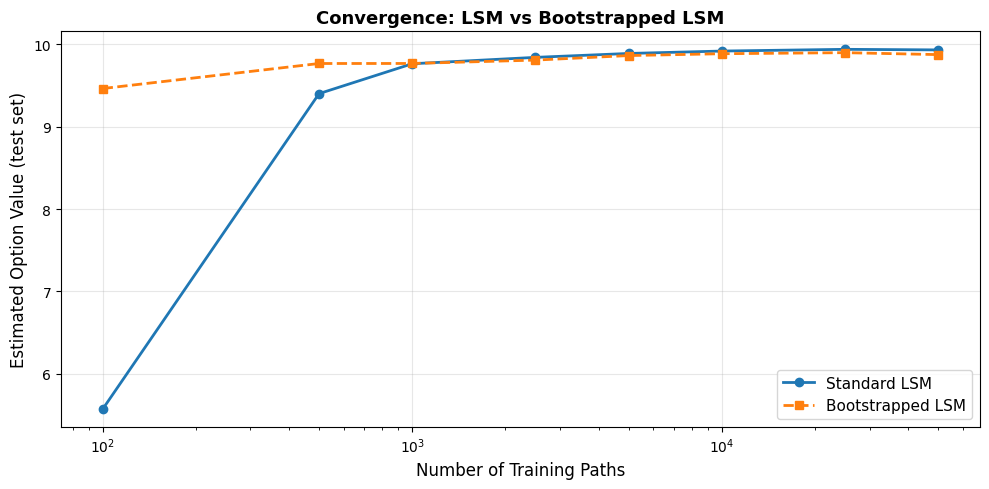

In [ ]:
# Convergence: How does value estimate change with number of training paths?
train_sizes = [100, 500, 1000, 2500, 5000, 10000, 25000, 50000]
lsm_values_by_n = []
td_values_by_n = []

for n in train_sizes:
    paths_n = generate_gbm_paths(params, n, seed=42)
    
    m_lsm = train_lsm(paths_n, params)
    m_td = train_td_lsm(paths_n, params)
    
    v_lsm, _, _ = evaluate_policy(m_lsm, test_paths, params)
    v_td, _, _ = evaluate_policy(m_td, test_paths, params)
    
    lsm_values_by_n.append(v_lsm)
    td_values_by_n.append(v_td)
    print(f"n={n:>6d}  LSM={v_lsm:.4f}  TD-LSM={v_td:.4f}")

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_sizes, lsm_values_by_n, 'o-', label='Standard LSM', linewidth=2)
ax.plot(train_sizes, td_values_by_n, 's--', label='TD-LSM', linewidth=2)
ax.set_xlabel('Number of Training Paths', fontsize=12)
ax.set_ylabel('Estimated Option Value (test set)', fontsize=12)
ax.set_title('Convergence: LSM vs TD-LSM', fontsize=13, fontweight='bold')
ax.set_xscale('log')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

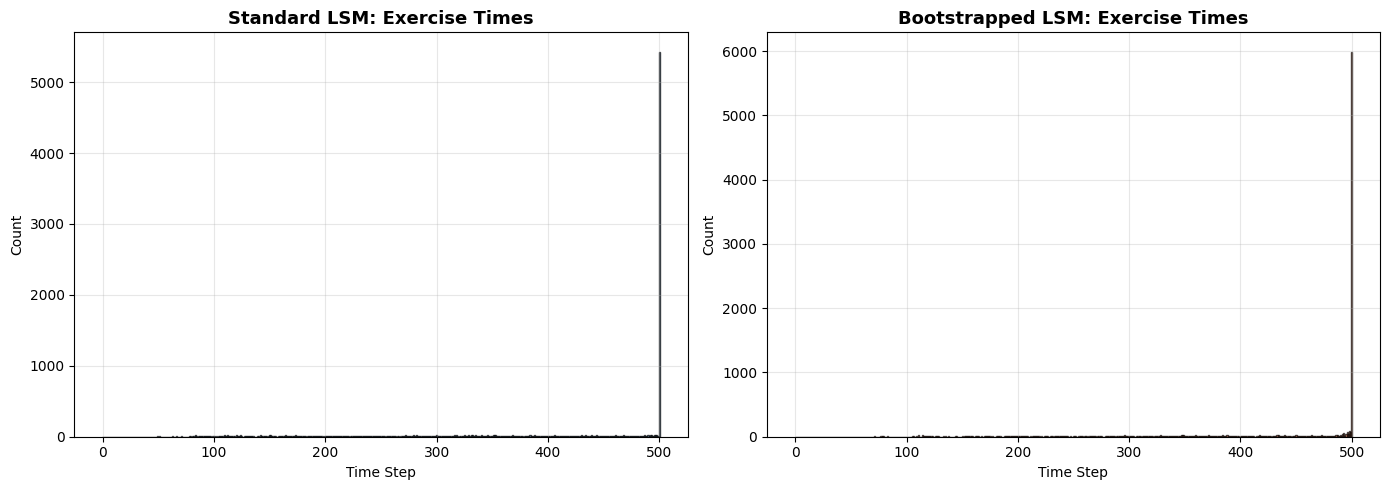

LSM  mean exercise time: 409.9
Boot mean exercise time: 437.4


In [ ]:
# Compare exercise time distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

bins = np.arange(0, params.N + 2) - 0.5

axes[0].hist(lsm_ex_times, bins=bins, alpha=0.7, color='steelblue', edgecolor='black')
axes[0].set_title('Standard LSM: Exercise Times', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Time Step')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].hist(td_ex_times, bins=bins, alpha=0.7, color='coral', edgecolor='black')
axes[1].set_title('TD-LSM: Exercise Times', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Time Step')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"LSM    mean exercise time: {lsm_ex_times.mean():.1f}")
print(f"TD-LSM mean exercise time: {td_ex_times.mean():.1f}")

In [ ]:
# Stability: variance across different training seeds
n_seeds = 10
n_train = 10000
lsm_vals = []
td_vals = []

for seed in range(n_seeds):
    p = generate_gbm_paths(params, n_train, seed=seed*100)
    m_lsm = train_lsm(p, params)
    m_td = train_td_lsm(p, params)
    v_lsm, _, _ = evaluate_policy(m_lsm, test_paths, params)
    v_td, _, _ = evaluate_policy(m_td, test_paths, params)
    lsm_vals.append(v_lsm)
    td_vals.append(v_td)

print(f"{'Method':<25} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}")
print("-" * 65)
print(f"{'Standard LSM':<25} {np.mean(lsm_vals):>10.4f} {np.std(lsm_vals):>10.4f} {np.min(lsm_vals):>10.4f} {np.max(lsm_vals):>10.4f}")
print(f"{'TD-LSM':<25} {np.mean(td_vals):>10.4f} {np.std(td_vals):>10.4f} {np.min(td_vals):>10.4f} {np.max(td_vals):>10.4f}")

Method                          Mean        Std        Min        Max
-----------------------------------------------------------------
Standard LSM                  9.9144     0.0235     9.8680     9.9408
Bootstrapped LSM              9.8489     0.0212     9.8193     9.8911


## Analysis

### When would TD-LSM outperform Standard LSM?

**Short answer: It probably won't for this problem.** Here's why:

1. **We have full paths.** Standard LSM uses the *actual realized cashflows* — it has access to the ground truth Monte Carlo returns. TD-LSM replaces this with *estimates*, which introduces bias. In RL, bootstrapping helps because we can't see the future. Here, we can.

2. **Bias vs Variance tradeoff.** TD-LSM has *lower variance* (each target depends only on the next step's regressor, not a long chain of future decisions) but *higher bias* (errors in the `t+1` regressor propagate backward). Standard LSM has higher variance (cashflows are noisy single-sample returns) but is *unbiased*.

3. **Where TD-LSM could help:**
   - **Very few training paths** — MC cashflows are very noisy with small samples; a TD target from a smooth regressor may be more stable.
   - **Very long horizons (large N)** — realized cashflows become noisier as the horizon grows; bootstrapping truncates the variance chain.
   - **Model misspecification** — if the polynomial basis doesn't capture the true continuation value well, bootstrapping from a smooth estimate may regularize better than noisy cashflows.

### Does it even make sense?

It's a valid idea but somewhat redundant in the offline setting. The power of TD bootstrapping in RL comes from *not having access to full trajectories* — the agent must learn online, step by step. In LSM, we simulate all paths upfront. The TD-LSM variant is essentially doing *fitted value iteration* instead of *policy iteration via regression on cashflows*.